In [17]:
## 1. Import Libraries
import pandas as pd
import numpy as np
import os

In [18]:
## 2. Explore Data Files
os.listdir()
os.listdir("../data")

['Telco_customer_churn.xlsx']

In [19]:
## 3. Load Dataset
df = pd.read_excel("../data/Telco_customer_churn.xlsx")

In [20]:
## 4. Initial Data Inspection
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [21]:
## 5. Data Quality Checks
df.isnull().sum()
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


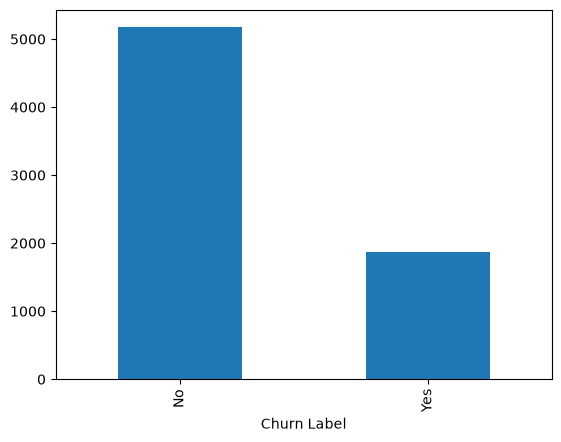

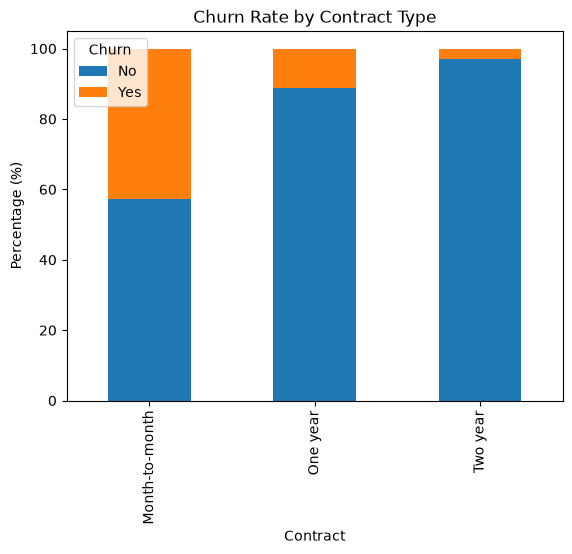

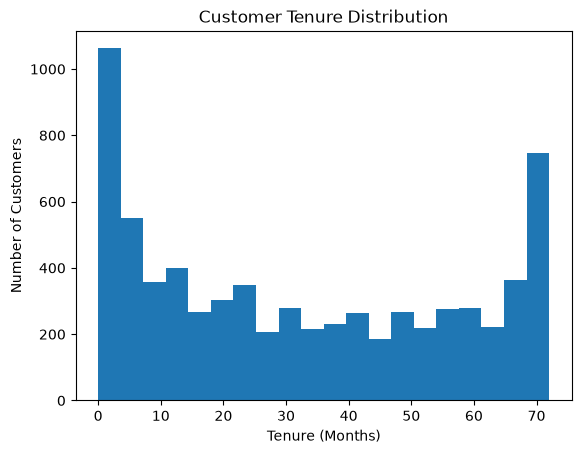

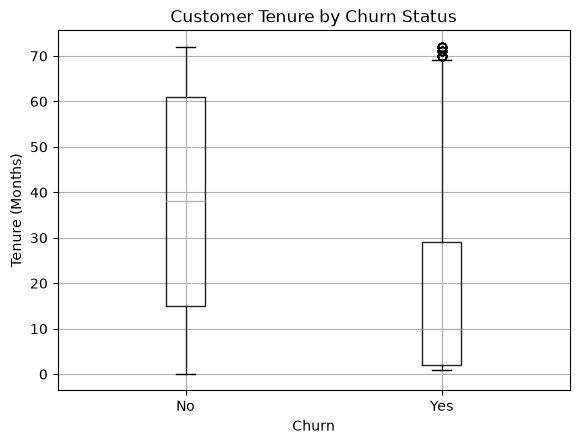

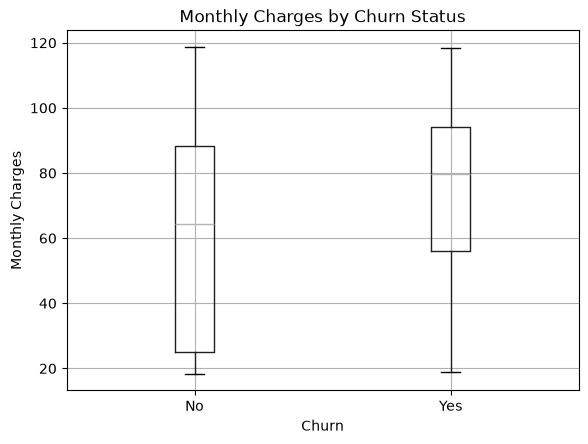

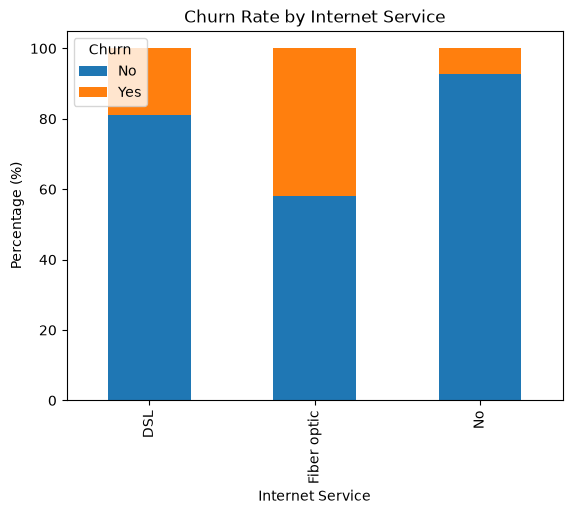

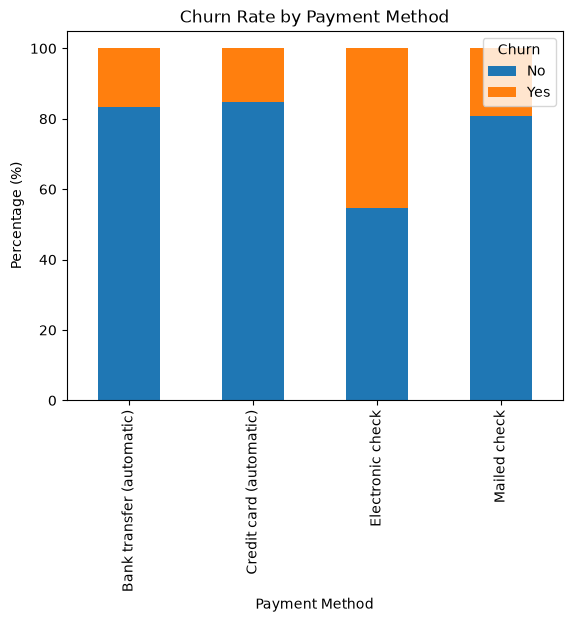

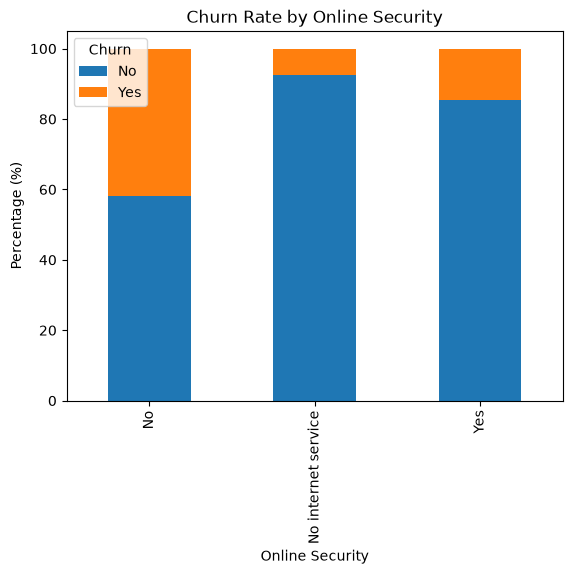

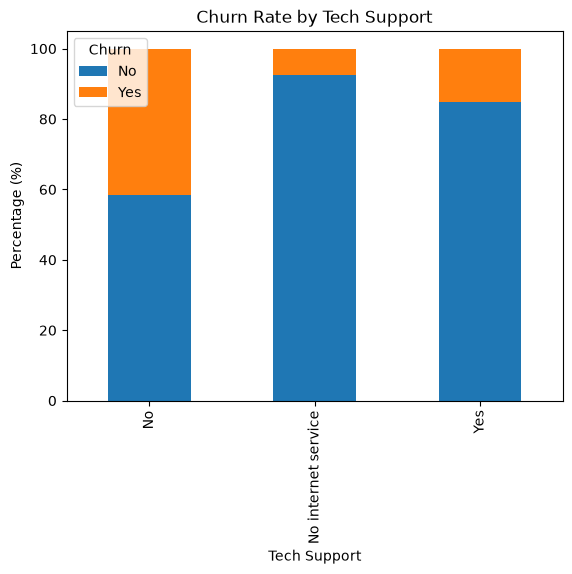

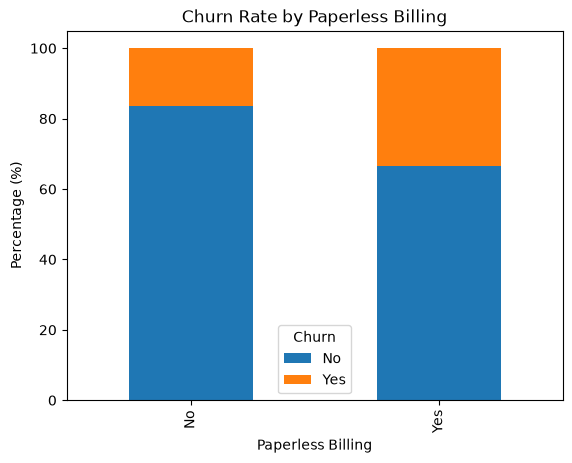

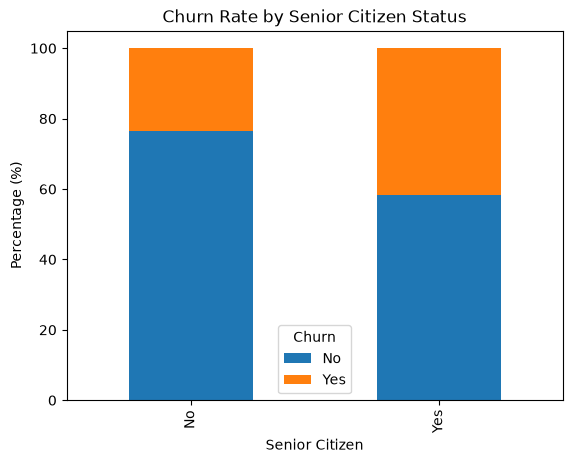

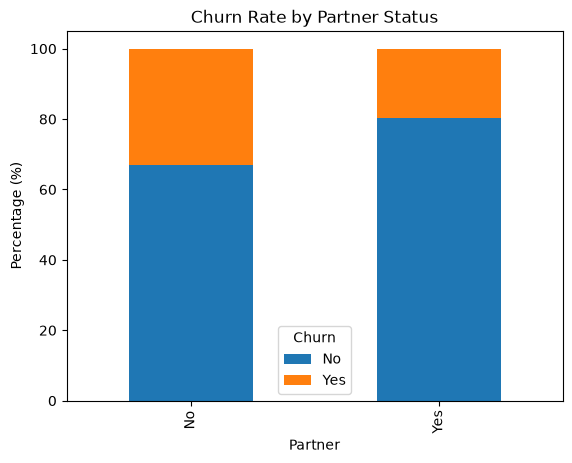

Missing values in target: 0
Duplicate rows: 0


In [22]:
## 6. Exploratory Data Analysis
df["Churn Label"].value_counts()
df["Churn Label"].value_counts(normalize=True) * 100
df["Churn Label"].value_counts().plot(kind="bar")
import matplotlib.pyplot as plt
plt.show()
df.groupby("Contract")["Churn Label"].value_counts()
pd.crosstab(df["Contract"], df["Churn Label"], normalize="index") * 100
pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
).mul(100).plot(
    kind="bar",
    stacked=True
)

plt.ylabel("Percentage (%)")
plt.xlabel("Contract")
plt.title("Churn Rate by Contract Type")
plt.legend(title="Churn")
plt.show()

df["Tenure Months"].plot(kind="hist", bins=20)

plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.title("Customer Tenure Distribution")
plt.show()

df.boxplot(column="Tenure Months", by="Churn Label")

plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.title("Customer Tenure by Churn Status")
plt.suptitle("")
plt.show()
# Analyze monthly charges by churn status
df.boxplot(column="Monthly Charges", by="Churn Label")

plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.title("Monthly Charges by Churn Status")
plt.suptitle("")
plt.show()
# Churned customers tend to have higher monthly charges than customers who stayed.
# Analyze churn rate by internet service

pd.crosstab(
    df["Internet Service"],
    df["Churn Label"],
    normalize="index"
).mul(100).plot(
    kind="bar",
    stacked=True
)

plt.ylabel("Percentage (%)")
plt.xlabel("Internet Service")
plt.title("Churn Rate by Internet Service")
plt.legend(title="Churn")
plt.show()
# Fiber optic customers have the highest churn rate among internet service types.
# Analyze churn rate by payment method
pd.crosstab(
    df["Payment Method"],
    df["Churn Label"],
    normalize="index"
).mul(100).plot(
    kind="bar",
    stacked=True
)

plt.ylabel("Percentage (%)")
plt.xlabel("Payment Method")
plt.title("Churn Rate by Payment Method")
plt.legend(title="Churn")
plt.show()
# Electronic check customers have the highest churn rate among payment methods.
# Analyze churn rate by online security service

pd.crosstab(
    df["Online Security"],
    df["Churn Label"],
    normalize="index"
).mul(100).plot(
    kind="bar",
    stacked=True
)

plt.ylabel("Percentage (%)")
plt.xlabel("Online Security")
plt.title("Churn Rate by Online Security")
plt.legend(title="Churn")
plt.show()

#Customers without Online Security have a higher churn rate
pd.crosstab(
    df["Tech Support"],
    df["Churn Label"],
    normalize="index"
).mul(100).plot(
    kind="bar",
    stacked=True
)

plt.ylabel("Percentage (%)")
plt.xlabel("Tech Support")
plt.title("Churn Rate by Tech Support")
plt.legend(title="Churn")
plt.show()
# Customers without tech support have the highest churn rate.

# Analyze churn rate by paperless billing

pd.crosstab(
    df["Paperless Billing"],
    df["Churn Label"],
    normalize="index"
).mul(100).plot(
    kind="bar",
    stacked=True
)

plt.ylabel("Percentage (%)")
plt.xlabel("Paperless Billing")
plt.title("Churn Rate by Paperless Billing")
plt.legend(title="Churn")
plt.show()
# Customers with paperless billing have a higher churn rate.

# Analyze churn rate by senior citizen status

pd.crosstab(
    df["Senior Citizen"],
    df["Churn Label"],
    normalize="index"
).mul(100).plot(
    kind="bar",
    stacked=True
)

plt.ylabel("Percentage (%)")
plt.xlabel("Senior Citizen")
plt.title("Churn Rate by Senior Citizen Status")
plt.legend(title="Churn")
plt.show()

# Senior citizens have a higher churn rate than non-senior citizens.

# Analyze churn rate by partner status

pd.crosstab(
    df["Partner"],
    df["Churn Label"],
    normalize="index"
).mul(100).plot(
    kind="bar",
    stacked=True
)

plt.ylabel("Percentage (%)")
plt.xlabel("Partner")
plt.title("Churn Rate by Partner Status")
plt.legend(title="Churn")
plt.show()
# Customers without a partner have a higher churn rate.

# Check missing values in target
print("Missing values in target:", df["Churn Label"].isnull().sum())
# Check duplicate rows

print("Duplicate rows:", df.duplicated().sum())
# Display all column names

df.columns.tolist()

target = "Churn Label"

features = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Tenure Months",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method",
    "Monthly Charges",
    "Total Charges"
]

In [23]:
## 7. Feature Selection

X = df[features].copy()
y = df[target]


# Check the shape of X and y

print("X shape:", X.shape)
print("y shape:", y.shape)

# Check data types of predictors

X.dtypes

# Check non-numeric values in Total Charges

pd.to_numeric(
    X["Total Charges"],
    errors="coerce"
).isnull().sum()

# Convert Total Charges to numeric

X["Total Charges"] = pd.to_numeric(
    X["Total Charges"],
    errors="coerce"
)


# Check data types again
X.dtypes


X shape: (7043, 19)
y shape: (7043,)


Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges        float64
dtype: object

In [24]:
## 8. Define Feature Types

numerical_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]



categorical_features = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method"
]

In [25]:
## 9. Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report

baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred_baseline))
print(classification_report(y_test, y_pred_baseline))


Training set: (5634, 19)
Testing set: (1409, 19)
Baseline Accuracy: 0.7345635202271115
              precision    recall  f1-score   support

          No       0.73      1.00      0.85      1035
         Yes       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409



c:\Users\HP\Desktop\customer-churn-ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\Desktop\customer-churn-ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\Desktop\customer-churn-ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [26]:
## 10.Data Preprocessing

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])



categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine numerical and categorical preprocessing

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])


Cross-Validation F1 Scores: [0.77427686 0.74608539 0.74569134 0.74054878 0.73543979]
Mean CV F1: 0.7484084325897823
Accuracy: 0.8019872249822569
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1035
         Yes       0.64      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



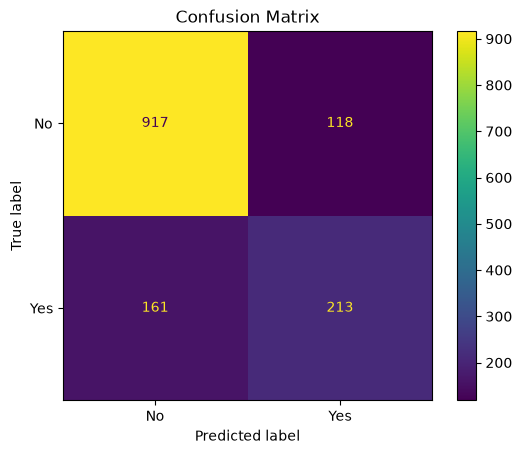

In [27]:
## 11. Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Train the model
model.fit(X_train, y_train) 

## Cross-Validation

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="f1_macro"
)

print("Cross-Validation F1 Scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())

# Make predictions on the test set
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()





In [28]:
## 12. Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

importances = rf_model.named_steps["classifier"].feature_importances_

feature_importance = pd.Series(
    importances,
    index=feature_names
).sort_values(ascending=False)

print(feature_importance.head(15))

y_pred_rf = rf_model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))


num__Total Charges                      0.154425
num__Monthly Charges                    0.131171
num__Tenure Months                      0.130956
cat__Contract_Month-to-month            0.051970
cat__Online Security_No                 0.030657
cat__Payment Method_Electronic check    0.030061
cat__Tech Support_No                    0.026693
cat__Internet Service_Fiber optic       0.024701
cat__Dependents_No                      0.021310
cat__Dependents_Yes                     0.021041
cat__Contract_Two year                  0.018641
cat__Online Backup_No                   0.018138
cat__Gender_Female                      0.017418
cat__Gender_Male                        0.017392
cat__Partner_No                         0.016340
dtype: float64
Accuracy: 0.7927608232789212

Classification Report:
              precision    recall  f1-score   support

          No       0.84      0.89      0.86      1035
         Yes       0.63      0.52      0.57       374

    accuracy                     

In [29]:
## 13. Model Comparison

from sklearn.metrics import precision_score, recall_score, f1_score

print("\n========== Model Comparison ==========")

print("\nLogistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision (Yes):", precision_score(y_test, y_pred, pos_label="Yes"))
print("Recall (Yes):", recall_score(y_test, y_pred, pos_label="Yes"))
print("F1 (Yes):", f1_score(y_test, y_pred, pos_label="Yes"))

print("\nRandom Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision (Yes):", precision_score(y_test, y_pred_rf, pos_label="Yes"))
print("Recall (Yes):", recall_score(y_test, y_pred_rf, pos_label="Yes"))
print("F1 (Yes):", f1_score(y_test, y_pred_rf, pos_label="Yes"))






========== Model Comparison ==========

Logistic Regression:
Accuracy: 0.8019872249822569
Precision (Yes): 0.6435045317220544
Recall (Yes): 0.56951871657754
F1 (Yes): 0.6042553191489362

Random Forest:
Accuracy: 0.7927608232789212
Precision (Yes): 0.6339869281045751
Recall (Yes): 0.5187165775401069
F1 (Yes): 0.5705882352941176


In [30]:
## 14.  ROC-AUC Comparison 

from sklearn.metrics import roc_auc_score

# Logistic Regression probability for the "Yes" class
y_prob = model.predict_proba(X_test)[:, 1]

# Random Forest probability for the "Yes" class
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Convert target labels to binary values: No = 0, Yes = 1
y_test_binary = (y_test == "Yes").astype(int)

# Calculate ROC-AUC for both models
roc_auc = roc_auc_score(y_test_binary, y_prob)
roc_auc_rf = roc_auc_score(y_test_binary, y_prob_rf)

print("Logistic Regression ROC-AUC:", roc_auc)
print("Random Forest ROC-AUC:", roc_auc_rf)

Logistic Regression ROC-AUC: 0.8487225193107547
Random Forest ROC-AUC: 0.8322328140742462


In [31]:
## 15) Threshold Tuning 

for threshold in [0.30, 0.35, 0.40, 0.45, 0.50]:

    y_pred_threshold = np.where(
        y_prob >= threshold,
        "Yes",
        "No"
    )

    report = classification_report(
        y_test,
        y_pred_threshold,
        labels=["No", "Yes"],
        output_dict=True
    )

    print(
        f"Threshold: {threshold} | "
        f"Accuracy: {report['accuracy']:.3f} | "
        f"Recall Yes: {report['Yes']['recall']:.3f} | "
        f"F1 Yes: {report['Yes']['f1-score']:.3f}"
    )


# Select a lower threshold to improve churn detection
final_threshold = 0.35

Threshold: 0.3 | Accuracy: 0.759 | Recall Yes: 0.746 | F1 Yes: 0.621
Threshold: 0.35 | Accuracy: 0.776 | Recall Yes: 0.717 | F1 Yes: 0.629
Threshold: 0.4 | Accuracy: 0.784 | Recall Yes: 0.674 | F1 Yes: 0.623
Threshold: 0.45 | Accuracy: 0.794 | Recall Yes: 0.628 | F1 Yes: 0.618
Threshold: 0.5 | Accuracy: 0.802 | Recall Yes: 0.570 | F1 Yes: 0.604


In [32]:
## 16. Final Model Evaluation
y_pred_final = np.where(
    y_prob >= final_threshold,
    "Yes",
    "No"
)

print("\nFinal Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_final,
        labels=["No", "Yes"]
    )
)

print("Final Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_final,
        labels=["No", "Yes"]
    )
)


Final Classification Report:
              precision    recall  f1-score   support

          No       0.89      0.80      0.84      1035
         Yes       0.56      0.72      0.63       374

    accuracy                           0.78      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.78      0.78      1409

Final Confusion Matrix:
[[825 210]
 [106 268]]


## 17. Conclusion

This project developed a machine learning model to predict customer churn using the Telco Customer Churn dataset.

Exploratory Data Analysis showed that churn is associated with several customer characteristics, including shorter tenure, higher monthly charges, month-to-month contracts, fiber optic internet service, and electronic check payment methods.

Logistic Regression performed better than Random Forest for detecting churn. Threshold tuning was then used to improve the model's ability to identify customers who are likely to churn.

The final threshold was set to 0.35, achieving the highest F1-score for the "Yes" class while also improving recall compared with the default threshold of 0.50.

Overall, this project demonstrates a complete machine learning workflow, including data exploration, feature selection, preprocessing, model training, cross-validation, model comparison, ROC-AUC evaluation, threshold tuning, and final model evaluation.
